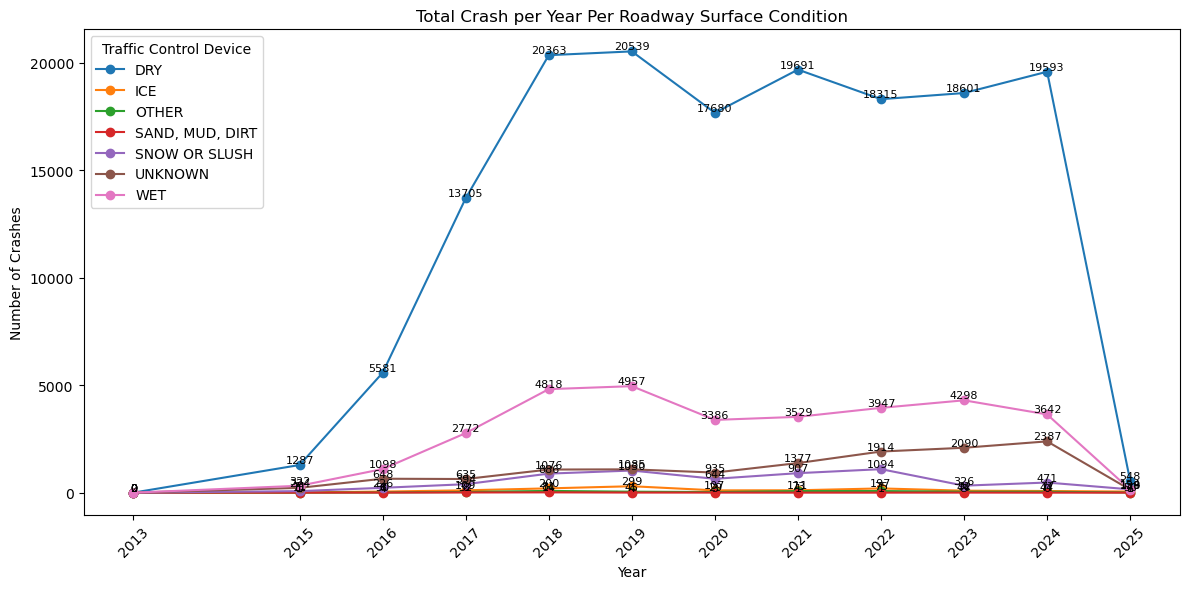

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Dataset
# Exploratory Data Analysis (EDA) - Line Chart Total Crash per Year Per Roadway Surface Condition
df = pd.read_csv("traffic_accidents.csv")

# Convert crash_date to datetime
df["crash_date"] = pd.to_datetime(df["crash_date"], format="%m/%d/%Y %I:%M:%S %p", errors="coerce")

# Extract year
df["year"] = df["crash_date"].dt.year

# Count total crash per year by roadway surface condition
yearly_crash = df.groupby(["year", "roadway_surface_cond"], observed=False).size().unstack(fill_value=0)

# Sort by year
yearly_crash = yearly_crash.sort_index()

# Line Chart
plt.figure(figsize=(12, 6))
for device in yearly_crash.columns:
    plt.plot(yearly_crash.index, yearly_crash[device], marker='o', label=device)
# Add labels
for device in yearly_crash.columns:
    for x, value in zip(yearly_crash.index, yearly_crash[device]):
        plt.text(x, value + 0.5, str(value), ha='center', va='bottom', fontsize=8)
plt.title("Total Crash per Year Per Roadway Surface Condition")
plt.xlabel("Year")
plt.ylabel("Number of Crashes")
plt.xticks(yearly_crash.index, rotation=45)
plt.legend(title="Traffic Control Device")
plt.tight_layout()
plt.show()